# Contour visualization
## Tables of contents

# Path

In [5]:
import os
from pathlib import Path
cache_path       = Path('/data/crcns2021/hcpannot-cache')
image_cache_path = cache_path / 'annot-images'
v123_cache_path  = cache_path / 'annot-v123'
csulc_cache_path = cache_path / 'annot-csulc'
# The save path of the data branch:
data_path = Path('/data/crcns2021/results/data_branch/save')
# The processing path and subpaths:
proc_path    = Path('/data/crcns2021/results/proc')

traces_path  = proc_path / 'traces'
paths_path   = proc_path / 'paths'
means_path   = proc_path / 'means'
labels_path  = proc_path / 'labels'
reports_path = proc_path / 'reports'
fig_dir      = proc_path / 'figures'

results_path = '/data/crcns2021/results'
contour_save_path = f'{results_path}/data_branch/save'

# The file of visual surface areas for the ventral data.
ventral_sarea_path = proc_path / 'ventral_sareas.tsv'

# The hcpannot library path; if hcpannot is not on the path for
# this notebook, the notebook will try to figure out where it is
# and will use this directory as a backup.
hcpannot_lib_path = Path('~/code/hcp-annot-vc_analysis')

# If you aren't using /data
os.environ['HCPANNOT_LOAD_PATH'] = os.fspath(cache_path)

# Dependencies

In [8]:
# import necessary packages
import sys
sys.path.append('../src/')
import hcpannot
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st 
import neuropythy as ny
import matplotlib as mpl
import itertools
import warnings
import pingouin as pg
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
sys.path.append('../src/hcpannot/')
from visualization import plot_annot_properties as vis
from visualization import twin_analysis as tw
from hcpannot.config import subject_list, ventral_raters, dorsal_raters, region_areas
from hcpannot.io import load_allreports
from hcpannot.proc import proc, proc_meanrater, proc_meansub

# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = str(cache_path)

# The subject IDs we are processing over, as a numpy array.
sids = np.array(subject_list)
hemis = ['lh', 'rh']

warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue'],
             'size': 12,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*3
mpl.rcParams['savefig.dpi'] = 72*4
mpl.rcParams['axes.unicode_minus'] = False

rc = {'text.color': 'black',
      'axes.labelcolor': 'black',
      'axes.labelweight': 'light',
      'axes.linewidth':     0.8,
      'xtick.major.width':    0.8,
      'ytick.major.width':    0.8,
      'xtick.color': 'black',
      'ytick.color': 'black',
      'xtick.labelcolor': 'black',
      'ytick.labelcolor': 'black',
      'font.family': 'helveticaneue',
      'font.weight': 'light',
      'font.size' : 12,
      'figure.dpi': 72*3,
      'savefig.dpi': 72*4,
      }
mpl.rcParams.update(rc)

#roi
roi_list = ['V1', 'V2', 'V3', 'hV4', 'VO','VO1', 'VO2']

/home/jiyeongha/.conda/envs/vwm/lib/python3.11/site-packages/IPython/core/events.py:93: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/jiyeongha/.conda/envs/vwm/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


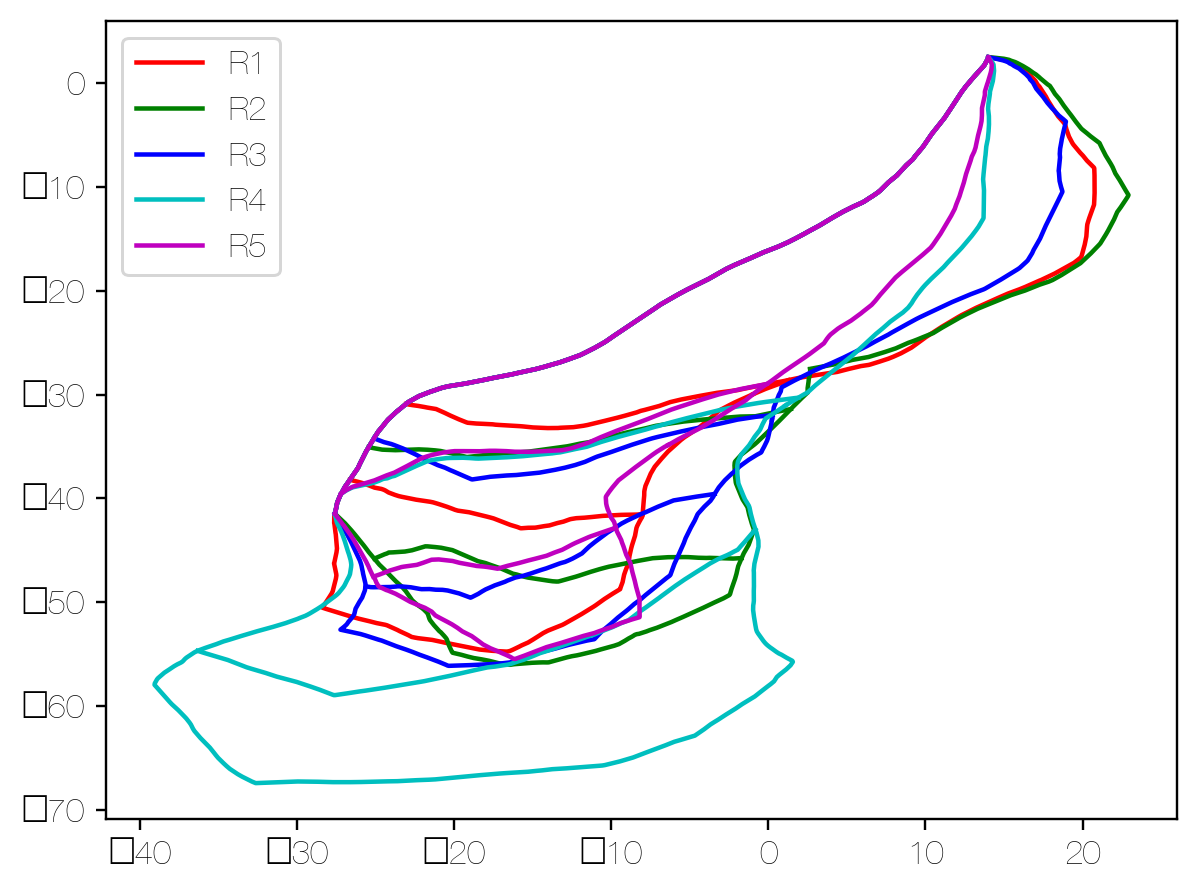

In [6]:
contours = ['hV4_outer','hV4_VO1','VO1_VO2','VO_outer', 'V3v']

hcpannot.analysis.plot_rater_contours(raters=ventral_raters, 
                                      subject_id=973770, 
                                      hemi='rh', 
                                      contours=contours, 
                                      save_path=proc_path, 
                                      data_path=contour_save_path)

In [12]:
# Get the HCP-lines dataset.
dset = ny.data['hcp_lines']

# To use individual subject contours (not aligned), we can use native_path_traces:
traces = dset.native_path_traces

In [16]:
    data = proc('ventral',
               rater=rater,
               sid=sid,
               hemisphere=hemi,
               save_path=proc_path,
               load_path=data_path)
data['contours']['hV4_outer']

FileNotFoundError: load_contours [R1/100610/lh] file not found for hV4_VO1: /data/crcns2021/results/data_branch/save/R1/100610/lh.hV4_VO1.json

FileNotFoundError: load_contours [R1/100610/lh] file not found for hV4_VO1: /data/crcns2021/results/data_branch/save/R1/100610/lh.hV4_VO1.json

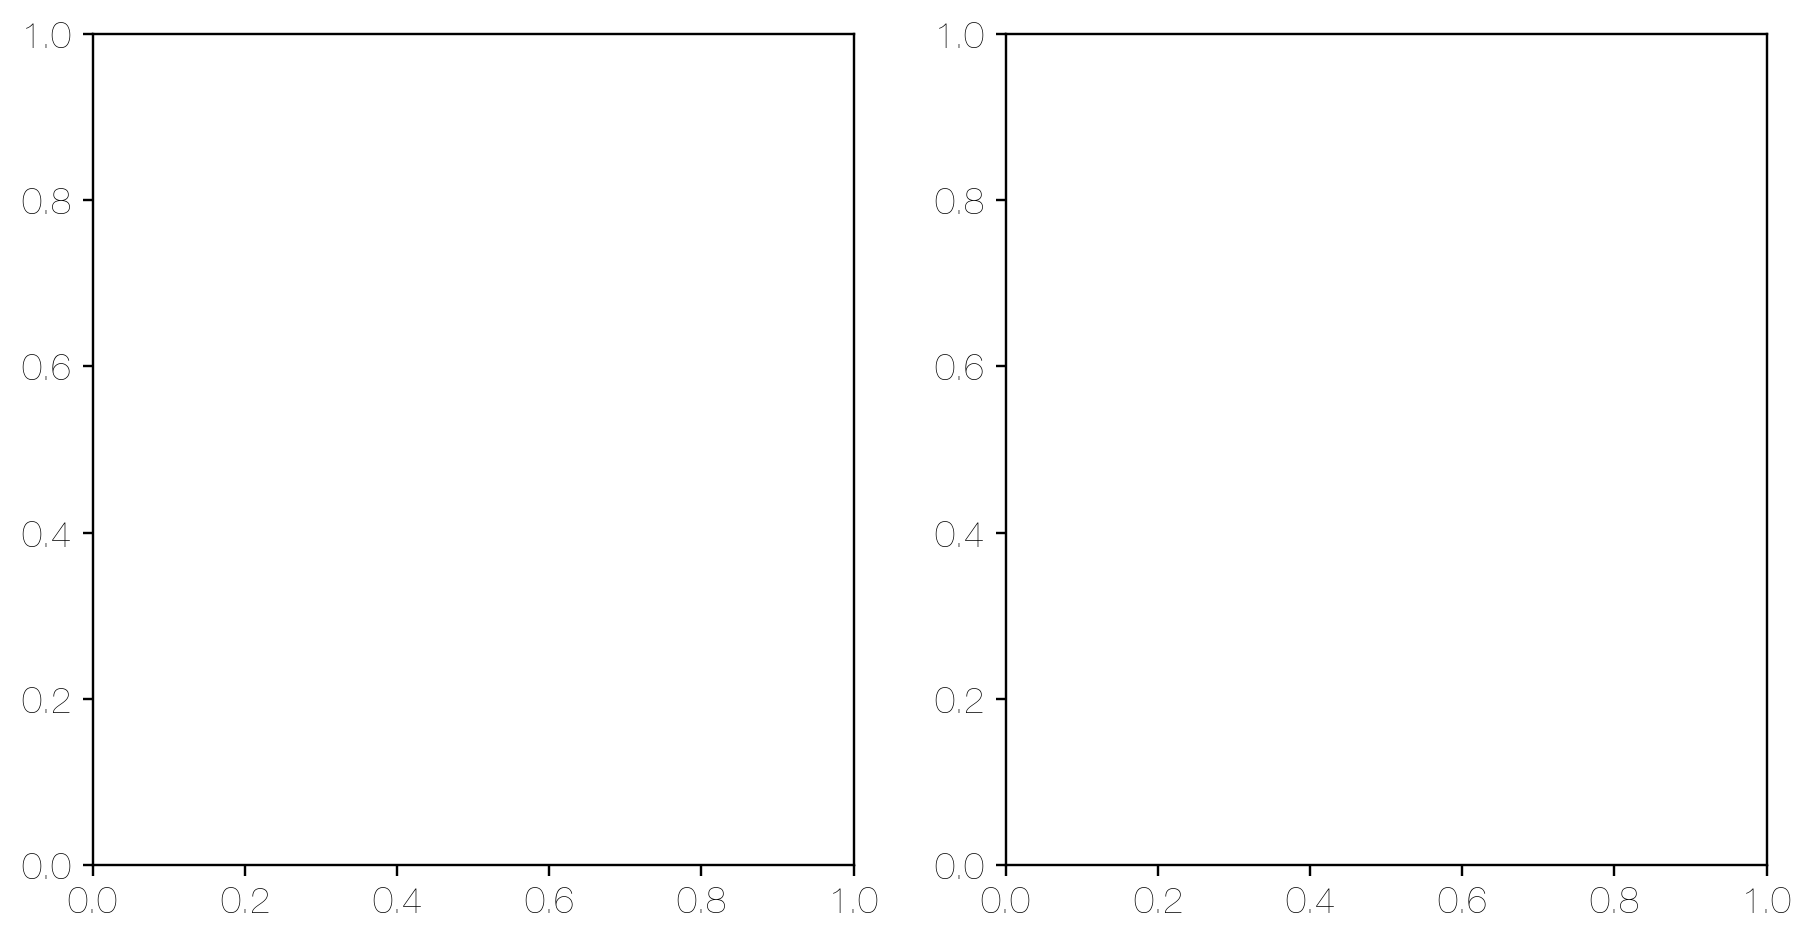

In [11]:
sid=100610
colors = plt.get_cmap('tab10').colors[:5]
fig, axes = plt.subplots(1,2, figsize=(10,5))
for i, rater in enumerate(ventral_raters):
    mask = ('prf_variance_explained', 0.1, 1)
    #ny.cortex_plot(data['flatmap'], color='prf_polar_angle', mask=mask, axes=axes)
    hemi='lh'
file = os.path.join(proc_path, 'fsaverage', f"cacherater_mean_{subject_id}_{hemi}_{name}.mgz") # if you are assessing the variability of the contours drawn by the same rater across subjects, the files should be cacherater_{rater}_{subject_id}...
                    coords = ny.load(file)
                    all_contours[name].append(coords)
    (x,y) = data['contours']['hV4_outer']
    axes[0].plot(x,y, 'o-', color=colors[i])

plt.show()